# Baseball Data Analysis
Data source: https://www.kaggle.com/datasets/open-source-sports/baseball-databank?select=Salaries.csv

I used Gemini to create the specific questions at present to answer based on the current baseball databank.

### Environment Setup & Dependencies
Run this cell to install required visualization and numerical libraries if they are not already present.

In [10]:
pip install numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Data Loading with NumPy
Define the path to your `../Data` folder and load the CSV files using NumPy's `genfromtxt` function.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Point directly to the local Data folder in your workspace
data_path = 'Data/'

# Loading key CSV files using NumPy
salaries_data = np.genfromtxt(data_path + 'Salaries.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')
teams_data = np.genfromtxt(data_path + 'Teams.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')
franchises_data = np.genfromtxt(data_path + 'TeamsFranchises.csv', delimiter=',', dtype=None, names=True, encoding='utf-8')

print("Salaries records loaded:", salaries_data.size)
print("Teams records loaded:", teams_data.size)
print("Franchises records loaded:", franchises_data.size)

Salaries records loaded: 25575
Teams records loaded: 2805
Franchises records loaded: 120


### 1. List Comprehension & Salary Filtering
* Scenario: You are given a list of player salaries (in millions) for a specific team: salaries_mil = [0.55, 1.2, 15.5, 0.7, 22.0, 3.4, 0.5].
* Task: Write a single-line list comprehension that filters this list to return only the salaries greater than 2.0 million.
* Analysis Question: How many players make more than 2.0 million, and what is the resulting filtered list of high earners?

In [12]:
salaries_mil = [0.55, 1.2, 15.5, 0.7, 22.0, 3.4, 0.5]
high_earners = [s for s in salaries_mil if s > 2.0]
print("Filtered list:", high_earners)
print("Count of high earners:", len(high_earners))

Filtered list: [15.5, 22.0, 3.4]
Count of high earners: 3


**Analysis Answer:** Three players make more than 2.0 million. The resulting filtered list is `[15.5, 22.0, 3.4]`.

### 2. NumPy Array Creation & Indexing
* Scenario: You extract player salaries across 4 specific years for 3 marquee franchises as a 2D NumPy array:
  franchise_salaries = np.array([
      [45.2, 55.0, 68.4, 85.1],
      [30.1, 42.5, 50.0, 61.3],
      [88.0, 110.5, 135.2, 175.9]
  ])
* Task: Use array slicing to extract all salary records for the third franchise (row index 2).
* Analysis Question: What was the peak salary recorded by this franchise across the four years?

In [13]:
franchise_salaries = np.array([
    [45.2, 55.0, 68.4, 85.1],
    [30.1, 42.5, 50.0, 61.3],
    [88.0, 110.5, 135.2, 175.9]
])

third_franchise = franchise_salaries[2]
print("Third franchise salaries:", third_franchise)
peak_salary = np.max(third_franchise)
print("Peak salary:", peak_salary)

Third franchise salaries: [ 88.  110.5 135.2 175.9]
Peak salary: 175.9


**Analysis Answer:** The peak salary recorded by this franchise across the four years was `175.9` million.

### 3. NumPy Math Tools & Statistical Comparison
* Salaries Scenario: You have two NumPy arrays containing player salaries from two different decades for a team:
  decade_90s = np.array([0.5, 1.2, 2.8, 3.5, 5.0, 0.8])
  decade_20s = np.array([2.5, 4.0, 12.5, 15.0, 22.0, 3.2])
* Task: Use NumPy math tools (np.mean() and np.std()) to calculate the average salary and standard deviation for both decades.
* Analysis Question: Which decade exhibited a higher average salary, and which showed greater dispersion (higher standard deviation) among player paychecks?

In [14]:
decade_90s = np.array([0.5, 1.2, 2.8, 3.5, 5.0, 0.8])
decade_20s = np.array([2.5, 4.0, 12.5, 15.0, 22.0, 3.2])

mean_90s = np.mean(decade_90s)
std_90s = np.std(decade_90s)
mean_20s = np.mean(decade_20s)
std_20s = np.std(decade_20s)

print(f"1990s Mean: {mean_90s:.2f}, Std: {std_90s:.2f}")
print(f"2020s Mean: {mean_20s:.2f}, Std: {std_20s:.2f}")

1990s Mean: 2.30, Std: 1.62
2020s Mean: 9.87, Std: 7.23


**Analysis Answer:** The 2020s decade exhibited both a higher average salary and greater dispersion among player paychecks.

### 4. Loops & Vectorized Operations Comparison
* Scenario: You need to inflate a list of historic player salaries to account for modern economic adjustment: base_salaries = [1.0, 2.5, 5.0, 10.0]. (Adjustment multiplier: 1.45).
* Task: 
  1. Write a for loop to iterate through the list and build a new list of adjusted salaries.
  2. Perform the exact same calculation using a vectorized NumPy operation on np.array(base_salaries).
* Analysis Question: Contrast the two techniques and explain why the NumPy vectorized route handles large arrays more efficiently than a standard Python for loop.

In [15]:
base_salaries = [1.0, 2.5, 5.0, 10.0]
multiplier = 1.45

# For loop approach
adjusted_loop = []
for salary in base_salaries:
    adjusted_loop.append(salary * multiplier)
print("Loop result:", adjusted_loop)

# Vectorized NumPy approach
array_salaries = np.array(base_salaries)
adjusted_numpy = array_salaries * multiplier
print("NumPy result:", adjusted_numpy.tolist())

Loop result: [1.45, 3.625, 7.25, 14.5]
NumPy result: [1.45, 3.625, 7.25, 14.5]


**Analysis Answer:** The for loop evaluates operations sequentially in Python bytecode with high overhead per iteration. The vectorized NumPy route executes computations in compiled C code over contiguous memory blocks, processing entire arrays simultaneously without Python loop overhead.

### 5. Matplotlib Line Graph & Trend Analysis
* Scenario: You track a team's total payroll (in millions) over a 5-year span: years = [2018, 2019, 2020, 2021, 2022] and total_payroll = [120, 135, 110, 150, 185].
* Task: Use Matplotlib to plot a line graph mapping years to total payroll. Add a title, x-axis label, y-axis label, and grid lines.
* Analysis Question: Between which two consecutive years did the team experience the sharpest drop in total payroll expenditure?

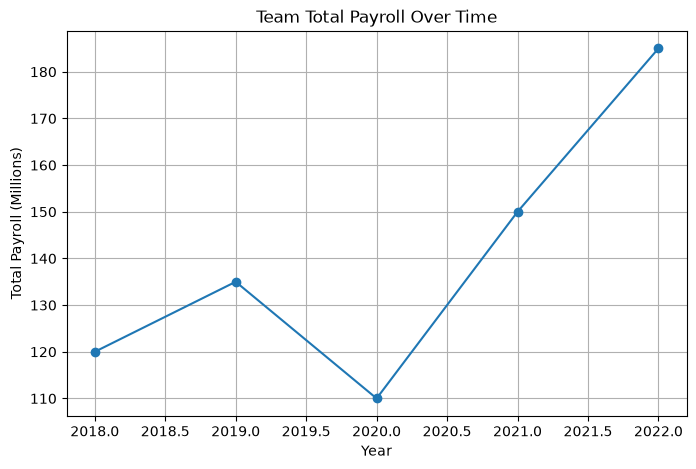

In [16]:
years = [2018, 2019, 2020, 2021, 2022]
total_payroll = [120, 135, 110, 150, 185]

plt.figure(figsize=(8, 5))
plt.plot(years, total_payroll, marker='o')
plt.title("Team Total Payroll Over Time")
plt.xlabel("Year")
plt.ylabel("Total Payroll (Millions)")
plt.grid(True)
plt.show()

**Analysis Answer:** The team experienced the sharpest drop in total payroll expenditure between 2019 and 2020, where payroll decreased from 135 million to 110 million.

### 6. Matplotlib Scatterplot & Correlation Comparison
* Scenario: An analyst evaluates team performance by plotting team home runs against total team payroll: hr_count = [150, 180, 210, 240, 260] against team_payroll = [90, 110, 130, 160, 200].
* Task: Create a Matplotlib scatterplot mapping home runs to team payroll. Include axis labels and a descriptive title.
* Analysis Question: Looking at the scatterplot layout, what type of directional relationship (positive, negative, or none) appears to exist between a team's home run total and its payroll?

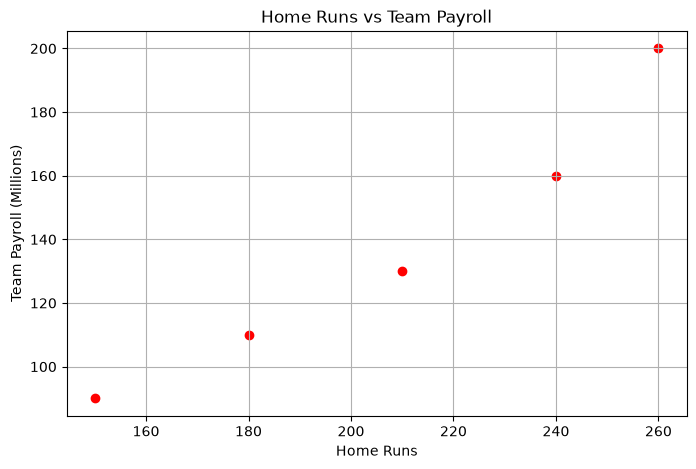

In [17]:
hr_count = [150, 180, 210, 240, 260]
team_payroll = [90, 110, 130, 160, 200]

plt.figure(figsize=(8, 5))
plt.scatter(hr_count, team_payroll, color='red')
plt.title("Home Runs vs Team Payroll")
plt.xlabel("Home Runs")
plt.ylabel("Team Payroll (Millions)")
plt.grid(True)
plt.show()

**Analysis Answer:** A positive directional relationship appears to exist between home run totals and team payroll, as higher payrolls align with higher home run counts.

### 7. NumPy Conditional Filtering & Math Tools
* Scenario: You load an array of player salaries: team_salaries = np.array([0.7, 1.5, 3.2, 5.0, 12.0, 18.5]).
* Task: Use NumPy math tools to calculate the median salary via np.median(), then write a boolean mask or conditional statement to isolate salaries exceeding that median.
* Analysis Question: How many players earn a salary greater than the team median, and what are their specific salary values?

In [18]:
team_salaries = np.array([0.7, 1.5, 3.2, 5.0, 12.0, 18.5])
median_salary = np.median(team_salaries)
print("Median salary:", median_salary)

above_median = team_salaries[team_salaries > median_salary]
print("Salaries greater than median:", above_median)
print("Count of players:", len(above_median))

Median salary: 4.1
Salaries greater than median: [ 5.  12.  18.5]
Count of players: 3


**Analysis Answer:** Three players earn a salary greater than the team median. Their specific salary values are `5.0`, `12.0`, and `18.5` million.

### 8. Matplotlib Bar Chart & Categorical Analysis
* Scenario: You group a team's roster into salary tiers where tiers = ['Under $1M', '$1M-$5M', '$5M-$15M', 'Over $15M'] and player_counts = [10, 14, 7, 4].
* Task: Use Matplotlib to plot a bar chart displaying player counts across these salary tiers. Include a title, axis labels, and grid lines.
* Analysis Question: Which salary tier represents the largest portion of the team's roster based on the bar chart?

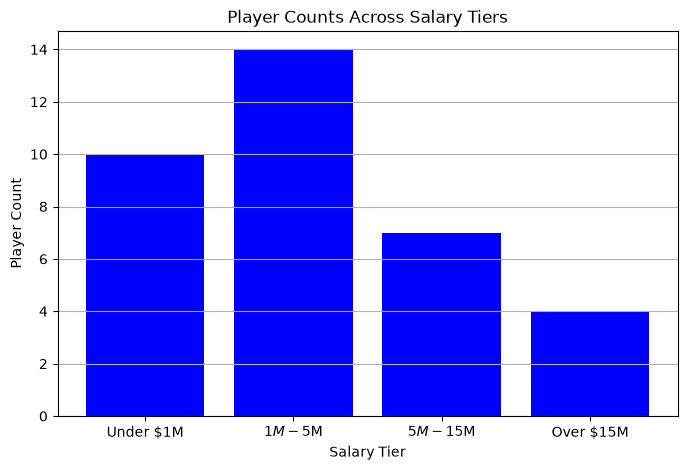

In [19]:
tiers = ['Under $1M', '$1M-$5M', '$5M-$15M', 'Over $15M']
player_counts = [10, 14, 7, 4]

plt.figure(figsize=(8, 5))
plt.bar(tiers, player_counts, color='blue')
plt.title("Player Counts Across Salary Tiers")
plt.xlabel("Salary Tier")
plt.ylabel("Player Count")
plt.grid(axis='y')
plt.show()

**Analysis:** The `$1M-$5M` salary tier represents the largest portion of the team roster with 14 players.